In [3]:
import pandas as pd

# 1. Đường dẫn tới 3 file trong thư mục train
sents_path = "../data/raw/train/sents.txt"
sentiments_path = "../data/raw/train/sentiments.txt"
topics_path = "../data/raw/train/topics.txt"

print("⏳ Đang đọc và gộp 3 file của bộ dữ liệu UIT-VSFC...")

try:
    # 2. Đọc từng file một cách an toàn (tránh lỗi dấu phẩy hay ký tự đặc biệt)
    with open(sents_path, 'r', encoding='utf-8') as f:
        sents = f.read().splitlines()
        
    with open(sentiments_path, 'r', encoding='utf-8') as f:
        sentiments = f.read().splitlines()
        
    with open(topics_path, 'r', encoding='utf-8') as f:
        topics = f.read().splitlines()
        
    # 3. Gom 3 list lại thành 1 DataFrame
    df = pd.DataFrame({
        'text': sents,
        'sentiment': sentiments, # Nhãn cảm xúc
        'topic': topics          # Nhãn chủ đề
    })
    
    print("✅ Đọc và gộp dữ liệu thành công!\n")
    
    # 4. Hiển thị thử 5 dòng đầu tiên
    print("👀 Xem thử 5 dòng đầu tiên của bảng dữ liệu:")
    display(df.head())
    
    # 5. In ra các thông số để đưa vào Báo cáo Word
    print("\n" + "="*40)
    print("📊 THỐNG KÊ KÍCH THƯỚC BỘ DỮ LIỆU")
    print("="*40)
    print(f"- Số lượng mẫu (câu phản hồi): {df.shape[0]} dòng")
    print(f"- Số lượng đặc trưng (cột): {df.shape[1]} cột")
    
    print("\n🔍 KIỂM TRA DỮ LIỆU THIẾU (Missing values):")
    print(df.isnull().sum())
    
    print("\n📈 PHÂN BỐ CÁC LỚP CẢM XÚC (Sentiment):")
    dist_sentiment = pd.DataFrame({
        'Số lượng': df['sentiment'].value_counts(), 
        'Tỷ lệ (%)': (df['sentiment'].value_counts(normalize=True) * 100).round(2)
    })
    display(dist_sentiment)
    
    print("\n📈 PHÂN BỐ CÁC LỚP CHỦ ĐỀ (Topic):")
    dist_topic = pd.DataFrame({
        'Số lượng': df['topic'].value_counts(), 
        'Tỷ lệ (%)': (df['topic'].value_counts(normalize=True) * 100).round(2)
    })
    display(dist_topic)

except FileNotFoundError as e:
    print(f"❌ Lỗi: Không tìm thấy file. Chi tiết: {e}")

⏳ Đang đọc và gộp 3 file của bộ dữ liệu UIT-VSFC...
✅ Đọc và gộp dữ liệu thành công!

👀 Xem thử 5 dòng đầu tiên của bảng dữ liệu:


,text,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0



📊 THỐNG KÊ KÍCH THƯỚC BỘ DỮ LIỆU
- Số lượng mẫu (câu phản hồi): 11426 dòng
- Số lượng đặc trưng (cột): 3 cột

🔍 KIỂM TRA DỮ LIỆU THIẾU (Missing values):
text         0
sentiment    0
topic        0
dtype: int64

📈 PHÂN BỐ CÁC LỚP CẢM XÚC (Sentiment):


,Số lượng,Tỷ lệ (%)
sentiment,,
2,5643,49.39
0,5325,46.60
1,458,4.01



📈 PHÂN BỐ CÁC LỚP CHỦ ĐỀ (Topic):


,Số lượng,Tỷ lệ (%)
topic,,
0,8166,71.47
1,2201,19.26
3,562,4.92
2,497,4.35


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12944\10193394.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_12944\10193394.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='topic', palette='magma')


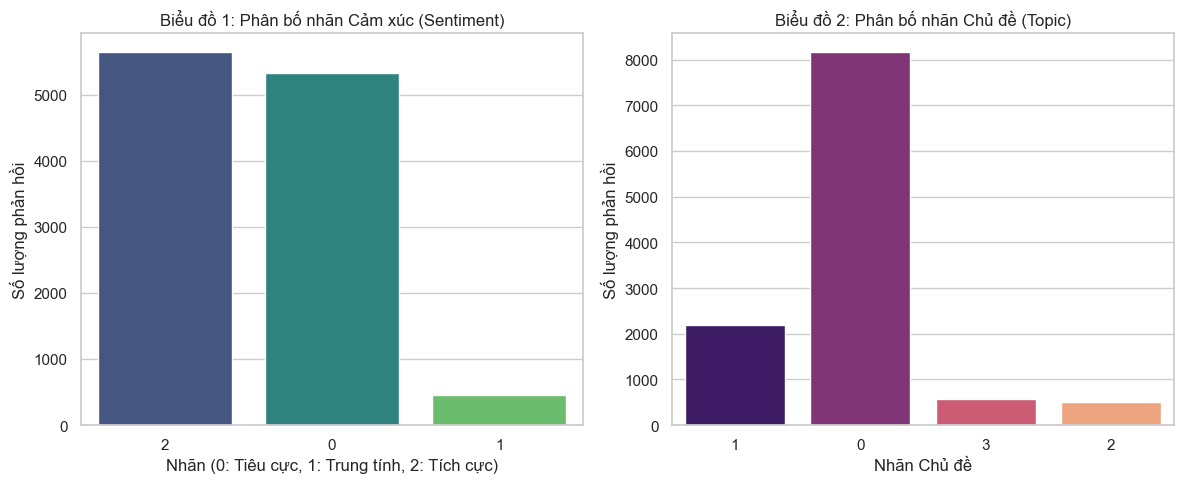


⏳ Đang tiến hành làm sạch dữ liệu...
- Đã xóa 1 dòng trùng lặp.
✅ Đã làm sạch xong! Xem thử kết quả:


,text,clean_text
0,slide giáo trình đầy đủ .,slide giáo trình đầy đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",nhiệt tình giảng dạy gần gũi với sinh viên
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy đủ full điểm chuyên cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp dụng công nghệ thông tin và các thiết ...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",thầy giảng bài hay có nhiều bài tập ví dụ ngay...


📁 Đã lưu file sạch vào: ../data/processed/train_cleaned.csv


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

# ---------------------------------------------------------
# 1. VẼ 2 BIỂU ĐỒ PHÂN TÍCH (Bắt buộc cho báo cáo)
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Biểu đồ 1: Phân bố Cảm xúc
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='sentiment', palette='viridis')
plt.title('Biểu đồ 1: Phân bố nhãn Cảm xúc (Sentiment)')
plt.xlabel('Nhãn (0: Tiêu cực, 1: Trung tính, 2: Tích cực)')
plt.ylabel('Số lượng phản hồi')

# Biểu đồ 2: Phân bố Chủ đề
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='topic', palette='magma')
plt.title('Biểu đồ 2: Phân bố nhãn Chủ đề (Topic)')
plt.xlabel('Nhãn Chủ đề')
plt.ylabel('Số lượng phản hồi')

plt.tight_layout()
plt.show() # Chụp cái hình này dán vào báo cáo nhé!

# ---------------------------------------------------------
# 2. LÀM SẠCH DỮ LIỆU CƠ BẢN (Text Cleaning)
# ---------------------------------------------------------
print("\n⏳ Đang tiến hành làm sạch dữ liệu...")

# Xóa các dòng trùng lặp (nếu có)
rows_before = df.shape[0]
df = df.drop_duplicates(subset=['text'])
print(f"- Đã xóa {rows_before - df.shape[0]} dòng trùng lặp.")

# Hàm làm sạch văn bản cơ bản
def clean_text(text):
    text = str(text).lower() # Viết thường
    text = re.sub(r'[^\w\s]', ' ', text) # Xóa dấu câu (.,!?)
    text = re.sub(r'\s+', ' ', text).strip() # Xóa khoảng trắng thừa
    return text

# Áp dụng hàm làm sạch vào cột text
df['clean_text'] = df['text'].apply(clean_text)

print("✅ Đã làm sạch xong! Xem thử kết quả:")
display(df[['text', 'clean_text']].head())

# ---------------------------------------------------------
# 3. LƯU LẠI DỮ LIỆU ĐÃ XỬ LÝ (Để tuần sau dùng, khỏi gộp lại)
# ---------------------------------------------------------
processed_path = "../data/processed/train_cleaned.csv"
df.to_csv(processed_path, index=False, encoding='utf-8')
print(f"📁 Đã lưu file sạch vào: {processed_path}")

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
import time

# ---------------------------------------------------------
# Bước 1: NẠP DỮ LIỆU ĐÃ LÀM SẠCH
# ---------------------------------------------------------
print("⏳ Đang nạp dữ liệu...")
df = pd.read_csv("../data/processed/train_cleaned.csv")

# Xóa các dòng bị rỗng sau quá trình làm sạch (nếu có)
df = df.dropna(subset=['clean_text', 'sentiment'])

# ---------------------------------------------------------
# Bước 2: CHIA TẬP TRAIN / TEST
# ---------------------------------------------------------
# Dành 80% để huấn luyện (Train) và 20% để kiểm tra (Test)
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✅ Đã chia dữ liệu: {X_train.shape[0]} câu Train, {X_test.shape[0]} câu Test.")

# ---------------------------------------------------------
# Bước 3: TRÍCH XUẤT ĐẶC TRƯNG BẰNG TF-IDF
# ---------------------------------------------------------
print("\n⏳ Đang chuyển đổi văn bản thành Vector bằng TF-IDF...")
# max_features=5000 giúp giới hạn từ vựng, tránh ma trận quá lớn gây chậm máy
vectorizer = TfidfVectorizer(max_features=5000) 

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(f"✅ TF-IDF hoàn tất! Kích thước ma trận Train: {X_train_tfidf.shape}")

# ---------------------------------------------------------
# Bước 4: HUẤN LUYỆN VÀ ĐÁNH GIÁ - LOGISTIC REGRESSION
# ---------------------------------------------------------
print("\n" + "="*50)
print("🤖 MÔ HÌNH 1: LOGISTIC REGRESSION")
print("="*50)

start_time = time.time()
# Khởi tạo và huấn luyện
lr_model = LogisticRegression(max_iter=1000) # max_iter lớn để đảm bảo hội tụ
lr_model.fit(X_train_tfidf, y_train)
lr_time = time.time() - start_time

# Dự đoán và Đánh giá
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"⏱️ Thời gian huấn luyện: {lr_time:.2f} giây")
print(classification_report(y_test, y_pred_lr, target_names=['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']))

# ---------------------------------------------------------
# Bước 5: HUẤN LUYỆN VÀ ĐÁNH GIÁ - SUPPORT VECTOR MACHINE (SVM)
# ---------------------------------------------------------
print("\n" + "="*50)
print("🤖 MÔ HÌNH 2: SUPPORT VECTOR MACHINE (SVM)")
print("="*50)

start_time = time.time()
# Khởi tạo SVM (dùng kernel='linear' vì text thường phân tách tốt bằng đường thẳng)
svm_model = SVC(kernel='linear') 
svm_model.fit(X_train_tfidf, y_train)
svm_time = time.time() - start_time

# Dự đoán và Đánh giá
y_pred_svm = svm_model.predict(X_test_tfidf)
print(f"⏱️ Thời gian huấn luyện: {svm_time:.2f} giây")
print(classification_report(y_test, y_pred_svm, target_names=['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']))

⏳ Đang nạp dữ liệu...
✅ Đã chia dữ liệu: 9140 câu Train, 2285 câu Test.

⏳ Đang chuyển đổi văn bản thành Vector bằng TF-IDF...
✅ TF-IDF hoàn tất! Kích thước ma trận Train: (9140, 2232)

🤖 MÔ HÌNH 1: LOGISTIC REGRESSION
⏱️ Thời gian huấn luyện: 0.15 giây
                precision    recall  f1-score   support

  Tiêu cực (0)       0.87      0.95      0.91      1051
Trung tính (1)       0.73      0.08      0.15        96
  Tích cực (2)       0.92      0.91      0.92      1138

      accuracy                           0.89      2285
     macro avg       0.84      0.65      0.66      2285
  weighted avg       0.89      0.89      0.88      2285


🤖 MÔ HÌNH 2: SUPPORT VECTOR MACHINE (SVM)
⏱️ Thời gian huấn luyện: 6.05 giây
                precision    recall  f1-score   support

  Tiêu cực (0)       0.88      0.95      0.92      1051
Trung tính (1)       0.75      0.06      0.12        96
  Tích cực (2)       0.92      0.93      0.92      1138

      accuracy                           0.90  

In [1]:
# Import các thư viện cốt lõi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyvi import ViTokenizer

# Cấu hình biểu đồ cho đẹp
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Môi trường đã sẵn sàng! Đã nạp đầy đủ đồ nghề.")

✅ Môi trường đã sẵn sàng! Đã nạp đầy đủ đồ nghề.


f:\Workspace\PYTHON\Projects\Baseline2\.venv\Lib\site-packages\pyvi\ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)
